# Simulate exoplanet radial velocity data

This notebook shows how to generate simulated data to test the routines to fit transits and RV orbit of exoplanets


In [1]:
import os, sys
import numpy as np
from numpy import random
import matplotlib.pyplot as plt

Import the library `exoplanetlib.py` with the main functions :

In [3]:
sys.path.append("/Volumes/Samsung_T5/ExoplanetAnalysis/")
from exoplanet_analysis import exoplanetlib
from exoplanet_analysis import rvutils

Set characteristics of the simulated data:

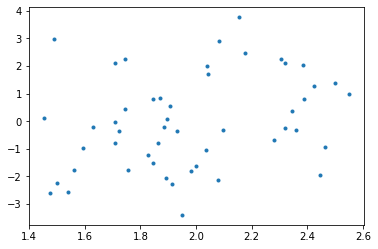

In [4]:
# Time range to be considered
T1, T2 = 59000, 59700
# Number of observations
nobs = 50
# Error per observation in m/s
rverr = 2.0 + (random.rand(nobs) - 0.5) * 1.1
rvinc = np.zeros_like(rverr)
for i in range(nobs) :
    rvinc[i] = np.random.normal(0., rverr[i], 1)
plt.plot(rverr,rvinc,'.')
# Set time array of observations:
obstimes = T1 + (T2-T1)*random.rand(nobs)
obstimes = obstimes[np.argsort(obstimes)]
# Set time array of model
timesampling = 0.1
times = np.arange(T1, T2, timesampling)

Set characteristics of the system:

In [14]:
star_mass = 1.0 # in solar mass
star_radius = 1.408 # in solar radius 
star_teff = 5656.0 # in kelvin
n_planets = 3
k,tc,per,ecc,w = np.empty(n_planets), np.empty(n_planets), np.empty(n_planets), np.empty(n_planets), np.empty(n_planets)
k[0] = 192.7642295075 # in m/s
tc[0] = 2017.5372409206684 # in the same time units
per[0] = 1092.1064993618 # in days
ecc[0] = 0.4977170152 
w[0] = 155.3973626121 # in degrees
k[1] = 3.1368093376 # in m/s
tc[1] = 1794.1769480556 # in the same time units
per[1] = 7.07320726
ecc[1] = 0.0
w[1] = 90.0 # in degrees
k[2] = 18.3919627691 # in m/s
tc[2] = 1890.617553292701 # in the same time units
per[2] = 321.0595765775 # in days
ecc[2] = 0.1820691525
w[2] = 146.9173575421 # in degrees
rvsys = -25.3 # in km/s

Text(0.5, 0, 'time [rjd]')

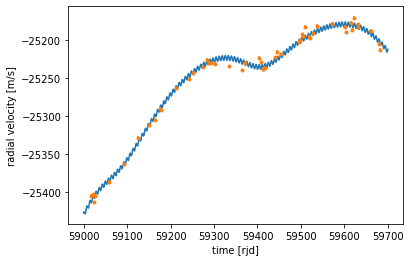

In [15]:
obsrvs = np.full_like(obstimes, rvsys*1000)
obsmodel = np.full_like(obstimes, rvsys*1000)
rvs = np.full_like(times, rvsys*1000)

for j in range(n_planets) :
    tp = exoplanetlib.timetrans_to_timeperi(tc[j], per[j], ecc[j], w[j])
    obsmodel += exoplanetlib.rv_model(obstimes, per[j], tp, ecc[j], w[j], k[j])
    obsrvs += exoplanetlib.rv_model(obstimes, per[j], tp, ecc[j], w[j], k[j]) + rvinc
    rvs += exoplanetlib.rv_model(times, per[j], tp, ecc[j], w[j], k[j])

plt.plot(times, rvs, '-')
plt.errorbar(obstimes,obsrvs,yerr=rverr,fmt='.')
plt.ylabel("radial velocity [m/s]")
plt.xlabel("time [rjd]")

Text(0.5, 0, 'time [rjd]')

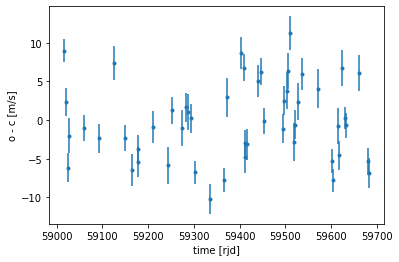

In [16]:
plt.errorbar(obstimes,obsrvs-obsmodel,yerr=rverr,fmt='.')
plt.ylabel("o - c [m/s]")
plt.xlabel("time [rjd]")

# Next steps
* Save simulated data in *.rdb
* Save model parameters in *.pars
* Recover parameters from fit routines

In [20]:
output_rdb_file = "/Volumes/Samsung_T5/Science/TOI-1736/TOI-1736_simul.rdb"
output_param_file = "/Volumes/Samsung_T5/Science/TOI-1736/TOI-1736_simul.pars"

In [18]:
bjds = obstimes + 2400000.
rvutils.save_rv_time_series(output_rdb_file, bjds, obsrvs/1000, rverr/1000, time_in_rjd=True, rv_in_mps=False)

In [19]:
outfile = open(output_param_file,"w+")
outfile.write("# Parameter_ID\tPrior_Type\tValues\n")
outfile.write("teff\tFIXED\t{:.0f}\n".format(star_teff))
outfile.write("ms\tFIXED\t{:.3f}\n".format(star_mass))
outfile.write("rs\tFIXED\t{:.3f}\n".format(star_radius))
#rhos = exoplanetlib.star_density(ms, rs)
#outfile.write("rhos\tFIXED\t{:.3f}\n".format(rhos))
outfile.write("n_planets\tFIXED\t{}\n".format(n_planets))
for i in range(n_planets) :
    outfile.write("tc_{:03d}\tUniform\t{:.8f},{:.8f},{:.8f}\n".format(i,tc[i]-0.1*per[i],tc[i]+0.1*per[i],tc[i]))
    outfile.write("per_{:03d}\tUniform\t{:.8f},{:.8f},{:.8f}\n".format(i,per[i]*0.8,per[i]*1.2,per[i]))
    outfile.write("ecc_{:03d}\tUniform\t0,1,{:.5f}\n".format(i,ecc[i]))
    outfile.write("w_{:03d}\tUniform\t0.,360.,{:.3f}\n".format(i,w[i]))
    outfile.write("k_{:03d}\tUniform\t-100,100.,{:.3f}\n".format(i,k[i]))
outfile.close()    